In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/social_media_addiction_dataset (1).csv")
df.head()

,daily_screen_time,app_opens,sleep_hours,stress_level,study_interruptions,night_usage,addiction_level
0,5.4,67,3.8,1,2,No,Moderate
1,4.3,10,6.9,2,7,No,Low
2,7.0,48,5.4,9,3,No,Moderate
3,12.0,16,6.7,2,0,No,Low
4,8.8,25,6.0,3,15,No,Moderate


In [5]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   daily_screen_time    1000 non-null   float64
 1   app_opens            1000 non-null   int64  
 2   sleep_hours          1000 non-null   float64
 3   stress_level         1000 non-null   int64  
 4   study_interruptions  1000 non-null   int64  
 5   night_usage          1000 non-null   object 
 6   addiction_level      1000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


(1000, 7)

In [7]:
df.isnull().sum()

,0
daily_screen_time,0
app_opens,0
sleep_hours,0
stress_level,0
study_interruptions,0
night_usage,0
addiction_level,0


In [9]:
x=df.drop('addiction_level',axis='columns')
y=df['addiction_level']

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in x.columns:
    if x[col].dtype=='object':
        x[col]=le.fit_transform(x[col])

In [12]:
if y.dtype=='object':
  y=le.fit_transform(y)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [17]:
model.score(X_test,y_test)

0.865

In [18]:
y_pred=model.predict(X_test)

In [19]:
print(y_pred[:10])

[2 0 2 2 2 2 2 2 2 2]


In [21]:
print("Actual Values:")
print(y_test[:10])
print("Predicted Values:")
print(y_pred[:10])

Actual Values:
[2 0 2 2 1 1 2 2 2 2]
Predicted Values:
[2 0 2 2 2 2 2 2 2 2]


In [22]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 20,   0,   9],
       [  0,   6,  16],
       [  1,   1, 147]])

confusion Matrix

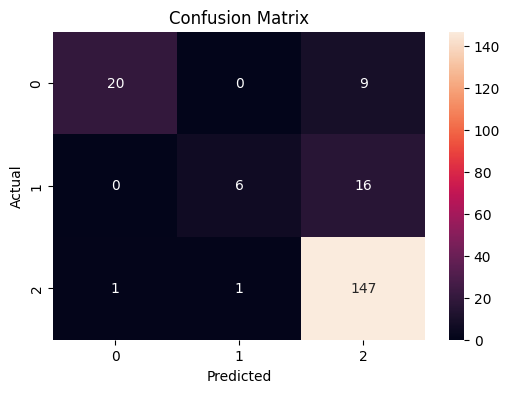

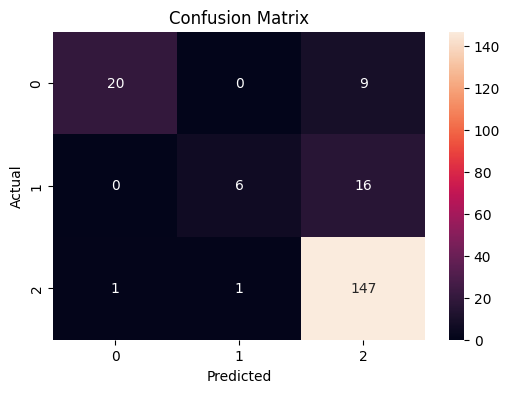

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

classification report

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.69      0.80        29
           1       0.86      0.27      0.41        22
           2       0.85      0.99      0.92       149

    accuracy                           0.86       200
   macro avg       0.89      0.65      0.71       200
weighted avg       0.87      0.86      0.84       200



save model

In [26]:
import joblib
joblib.dump(model, 'naive_bayes_model.joblib')

['naive_bayes_model.joblib']